In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [99]:
import sklearn

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.set_style('whitegrid')
sns.set_palette("husl")

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
%matplotlib inline

In [4]:
df = pd.read_csv('zomato.csv', encoding='latin-1')

# choosing encoding = "latin-1" here , because it handles the special characters in names. 




In [5]:
# PRECAUTION : Saving the dataframe , (just in c ase if something got deleted from the df doing cleaning )

df_original = df.copy()

In [6]:
print("Shape: ", df.shape)

Shape:  (51717, 17)


In [7]:
print("\nColumns:" , df.columns.tolist())


Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


In [8]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [10]:
df.describe()

#statistical summary of numeric columns



,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [11]:
df.describe(include="object")

#stat summary of text columns 

,url,address,name,online_order,book_table,rate,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
count,51717,51717,51717,51717,51717,43942,50509,51696,51490,23639,51672,51371,51717,51717,51717,51717
unique,51717,11495,8792,2,2,64,14926,93,93,5271,2723,70,22513,9098,7,30
top,https://www.zomato.com/bangalore/jalsa-banasha...,Delivery Only,Cafe Coffee Day,Yes,No,NEW,080 43334321,BTM,Quick Bites,Biryani,North Indian,300,[],[],Delivery,BTM
freq,1,128,96,30444,45268,2208,216,5124,19132,182,2913,7576,7595,39617,25942,3279


In [12]:
print("Null counts:")
df.isnull().sum()

Null counts:


url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [13]:
# Calc % of Null vals in respective columns
print("Null % per column:")
((df.isnull().sum()/len(df))*100).round(3)


Null % per column:


url                             0.000
address                         0.000
name                            0.000
online_order                    0.000
book_table                      0.000
rate                           15.034
votes                           0.000
phone                           2.336
location                        0.041
rest_type                       0.439
dish_liked                     54.292
cuisines                        0.087
approx_cost(for two people)     0.669
reviews_list                    0.000
menu_item                       0.000
listed_in(type)                 0.000
listed_in(city)                 0.000
dtype: float64

In [14]:
#Unique val per column

print("Unique Values : ")
print(df.nunique() )

Unique Values : 
url                            51717
address                        11495
name                            8792
online_order                       2
book_table                         2
rate                              64
votes                           2328
phone                          14926
location                          93
rest_type                         93
dish_liked                      5271
cuisines                        2723
approx_cost(for two people)       70
reviews_list                   22513
menu_item                       9098
listed_in(type)                    7
listed_in(city)                   30
dtype: int64


In [15]:
# Duplicate rows 

print("Duplicate rows: ", df.duplicated().sum())

Duplicate rows:  0


# Data Preprocessing

## 1. Removing Useless Columns

Since this project does not involve NLP tasks, the following text-based columns are removed:

- `url`
- `phone`
- `reviews_list`
- `menu_item`
- `dish_liked`

## 2. Data Type Conversion

The following columns are converted to appropriate numerical data types:

- `rate`: `str` → `float`
- `approx_cost`: `str` → `int`

## 3. Binary Encoding

The following categorical columns are encoded into binary values:

- `online_order`: `Yes` → `1`, `No` → `0`
- `book_table`: `Yes` → `1`, `No` → `0`

### Removing Useless Colums 

In [16]:
print("\nColumns:" , df.columns.tolist())


Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


In [17]:
cols_removed = ["url", "phone", "reviews_list" ,"menu_item", "dish_liked"]

In [18]:
df.drop(columns = cols_removed, inplace=True)


In [19]:
print("Remaining Columns: ", df.columns.tolist())

Remaining Columns:  ['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)']


### Renaming Columns for clarity 

In [20]:
df.rename(columns={ 

    "approx_cost(for two people)": "cost_for_two",
    "listed_in(type)" : "meal_type",
    "listed_in(city)" : "city",
    
}, inplace=True)


print(df.columns.tolist())

['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'cost_for_two', 'meal_type', 'city']


### Removing Duplicates (if any)  


In [21]:
# Duplicate rows 

print("Duplicate rows ( Before ): ", df.duplicated().sum())

Duplicate rows ( Before ):  85


In [22]:
#duplicates occurs bcz we removed some columns . 
df.drop_duplicates(inplace = True)
df.reset_index(drop=True, inplace = True)
print("Duplicates after: ", df.duplicated().sum())
print("Shape after dedup: ", df.shape)

Duplicates after:  0
Shape after dedup:  (51632, 12)


### Fixing the "rate" column
 Because this column contains many incosistent values ,
 which includes :
 - Ratings in the format `"4.5/5"` : will change this to float , and remove "/5"
 - Special vals such as : `"NEW"` and `"-"`
 - Missing vals : `"NaN"`

  At first ,Will change special vals to NaN
  then `"NaN"` with median or will see possibility to drop it. 

  Then will change the data type from `"str"` to `"float"`

In [23]:
print(df["rate"].unique()[:25])

<StringArray>
[ '4.1/5',  '3.8/5',  '3.7/5',  '3.6/5',  '4.6/5',  '4.0/5',  '4.2/5',
  '3.9/5',  '3.1/5',  '3.0/5',  '3.2/5',  '3.3/5',  '2.8/5',  '4.4/5',
  '4.3/5',    'NEW',  '2.9/5',  '3.5/5',      nan,  '2.6/5', '3.8 /5',
  '3.4/5',  '4.5/5',  '2.5/5',  '2.7/5']
Length: 25, dtype: str


In [24]:
print(df["rate"].dtype)

str


In [25]:
#Removing "/5" first 

df["rate"] = df["rate"].astype(str).str.replace("/5", "", regex=False).str.strip()

In [26]:
df["rate"] = df["rate"].replace(["NEW", "-", "nan", " -", ""], np.nan)
df["rate"].isnull().sum()


np.int64(10030)

In [27]:
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")
df["rate"].dtype

dtype('float64')

In [28]:
df["rate"].describe()

count    41602.000000
mean         3.700082
std          0.440417
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

In [29]:
# percentage of null/nan values : 
print("Percentage of nan values : ")
(df["rate"].isnull().sum()/len(df) )*100

Percentage of nan values : 


np.float64(19.42593740316083)

#### since we dont want to loose `~20% data` , will replace these nan values with `median` . 

In [30]:
df["rate"] = df["rate"].fillna(df["rate"].median() ,inplace = True)

print("Rate range:", df["rate"].min(),"to",df["rate"].max())

Rate range: 1.8 to 4.9


In [31]:
print(df["rate"].unique()[:65])

[4.1 3.8 3.7 3.6 4.6 4.  4.2 3.9 3.1 3.  3.2 3.3 2.8 4.4 4.3 2.9 3.5 2.6
 3.4 4.5 2.5 2.7 4.7 2.4 2.2 2.3 4.8 4.9 2.1 2.  1.8]


In [32]:
df["rate"].isna().sum()


np.int64(0)

### Fixing the cost Column

The `approx_cost(for two people)` column contains cost vals in string format and includes `" , "`, which makes it unsuitable for numerical analysis.

To clean this column, the following steps are performed:

1. Rename the column for simplicity.
2. Remove commas from values (e.g., "1,200" → "1200").
3. Convert the column from `string` to `integer` type.


In [33]:
print(df["cost_for_two"].unique()[:100])

<StringArray>
[  '800',   '300',   '600',   '700',   '550',   '500',   '450',   '650',
   '400',   '900',   '200',   '750',   '150',   '850',   '100', '1,200',
   '350',   '250',   '950', '1,000', '1,500', '1,300',   '199',    '80',
 '1,100',   '160', '1,600',   '230',   '130',    '50',   '190', '1,700',
     nan, '1,400',   '180', '1,350', '2,200', '2,000', '1,800', '1,900',
   '330', '2,500', '2,100', '3,000', '2,800', '3,400',    '40', '1,250',
 '3,500', '4,000', '2,400', '2,600',   '120', '1,450',   '469',    '70',
 '3,200',    '60',   '560',   '240',   '360', '6,000', '1,050', '2,300',
 '4,100', '5,000', '3,700', '1,650', '2,700', '4,500',   '140']
Length: 71, dtype: str


### Removing the ` ',' ` AND `""` and converting dtype from str -> int

In [34]:
df["cost_for_two"] = df["cost_for_two"].astype(str).str.replace(",", "", regex=False)


In [35]:
df["cost_for_two"] = pd.to_numeric(df["cost_for_two"], errors="coerce")


In [36]:
print(df["cost_for_two"].unique()[:100])

[ 800.  300.  600.  700.  550.  500.  450.  650.  400.  900.  200.  750.
  150.  850.  100. 1200.  350.  250.  950. 1000. 1500. 1300.  199.   80.
 1100.  160. 1600.  230.  130.   50.  190. 1700.   nan 1400.  180. 1350.
 2200. 2000. 1800. 1900.  330. 2500. 2100. 3000. 2800. 3400.   40. 1250.
 3500. 4000. 2400. 2600.  120. 1450.  469.   70. 3200.   60.  560.  240.
  360. 6000. 1050. 2300. 4100. 5000. 3700. 1650. 2700. 4500.  140.]


#### Tackling with nulls

In [37]:
print("Null cost: ")
print(df["cost_for_two"].isnull().sum())


Null cost: 
344


In [38]:


# description about "cost_for_two" column

print(df["cost_for_two"].describe())

count    51288.000000
mean       555.075749
std        438.528585
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: cost_for_two, dtype: float64


### Final check on Null values after this much cleaning

##### Printing `null report` : 
-  `count` & `percentage`


In [39]:
null_report = pd.DataFrame( {

    "null_count" : df.isnull().sum(),
    "null_perc" : (df.isnull().sum()/len(df) *100 ).round(3)
} )



print(null_report[null_report["null_count"] >0])
    

              null_count  null_perc
location              21      0.041
rest_type            227      0.440
cuisines              45      0.087
cost_for_two         344      0.666


## Review of the `null_report`

### Points Observed : 

- `cost_for_two` : ~0.67% null

  - will fill this with **median** value.
    

- Text columns ` rest_type , location , city, cuisines,` : ~ <1%

  Filling them with `"Unknown"` should be considered a reasonable approach

  

In [40]:
# Text columns -> Unknown

for col in ["cuisines", "rest_type", "location", "city", "meal_type"]:
    df[col] = df[col].fillna("Unknown")

In [41]:
# fill median in cost_for_two nulls

median_val = df["cost_for_two"].median()
df["cost_for_two"] = df["cost_for_two"].fillna(median_val)
print("Nulls remaining:", df["cost_for_two"].isnull().sum())

Nulls remaining: 0


In [42]:
# Final null_report : 

null_report = pd.DataFrame( {

    "null_count" : df.isnull().sum(),
    "null_perc" : (df.isnull().sum()/len(df) *100 ).round(3)
} )



print(null_report[null_report["null_count"] >0])
    



Empty DataFrame
Columns: [null_count, null_perc]
Index: []


In [43]:
print(df["cost_for_two"].unique()[:100])

[ 800.  300.  600.  700.  550.  500.  450.  650.  400.  900.  200.  750.
  150.  850.  100. 1200.  350.  250.  950. 1000. 1500. 1300.  199.   80.
 1100.  160. 1600.  230.  130.   50.  190. 1700. 1400.  180. 1350. 2200.
 2000. 1800. 1900.  330. 2500. 2100. 3000. 2800. 3400.   40. 1250. 3500.
 4000. 2400. 2600.  120. 1450.  469.   70. 3200.   60.  560.  240.  360.
 6000. 1050. 2300. 4100. 5000. 3700. 1650. 2700. 4500.  140.]


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51632 entries, 0 to 51631
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   address       51632 non-null  str    
 1   name          51632 non-null  str    
 2   online_order  51632 non-null  str    
 3   book_table    51632 non-null  str    
 4   rate          51632 non-null  float64
 5   votes         51632 non-null  int64  
 6   location      51632 non-null  str    
 7   rest_type     51632 non-null  str    
 8   cuisines      51632 non-null  str    
 9   cost_for_two  51632 non-null  float64
 10  meal_type     51632 non-null  str    
 11  city          51632 non-null  str    
dtypes: float64(2), int64(1), str(9)
memory usage: 4.7 MB


## Text Standardization 

Before further analysis , all the text cols will be standardized to ensure the consistency ;)
like : 

- **Whitespace removal** : Spaces comes before and after the texts will be removed
- **Consistent casing** : will convert all test to Ttitle Case  ( eg ; matar paneer -> Matar Paneer )

**Affected columns list** : `[ name , location , city , rest_type, cuisines, meal_type]`


-----------------------------------------------------------------------------------------------------------------

Additionally, `online_order` and `book_table` columns were checked for extra whitespace before converting them into binary (0/1) format.





******************************************************************************************************************

Above steps ensures consistency in categorical values and prevents duplication caused by case or spacing differences during analysis.


In [45]:
text_cols = ["name", "location", "city", "rest_type", "cuisines", "meal_type"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
    

In [46]:
# fixing whitespaces in online_order, book_table 

df["online_order"] = df["online_order"].astype(str).str.strip()
df["book_table"] = df["book_table"].astype(str).str.strip()


In [47]:
print(df["online_order"].value_counts())

online_order
Yes    30379
No     21253
Name: count, dtype: int64


In [48]:
print(df["book_table"].value_counts())

book_table
No     45212
Yes     6420
Name: count, dtype: int64


In [49]:
print("=" * 50)
print("             CLEANED DATASET SUMMARY                ")
print("=" * 50)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Nulls: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Rate dtype: {df['rate'].dtype}")
print(f"Cost dtype: {df['cost_for_two'].dtype}")
print("\n    Column dtypes:     ")
print(df.dtypes)

# Save cleaned file
df.to_csv("zomato_cleaned.csv", index=False)
print("\n")
print("Cleaned file saved!")

             CLEANED DATASET SUMMARY                
Rows: 51632
Columns: 12
Nulls: 0
Duplicates: 0
Rate dtype: float64
Cost dtype: float64

    Column dtypes:     
address             str
name                str
online_order        str
book_table          str
rate            float64
votes             int64
location            str
rest_type           str
cuisines            str
cost_for_two    float64
meal_type           str
city                str
dtype: object


Cleaned file saved!


 # Feature Engineering & Encoding 

 - We will create New columns from the existing ones . 
 - Makes correlation analysis possible. 

 ### Binary Encoding (Yes/No → 1/0)

 Because ML models cannot process text.


 We will use `map()` approach here. 
 - cleanest , readable & easy to understand
 - also the most commonly used approach for binary encoding categorical values
 - will creates a new encoded column
   

In [50]:
df["online_order_enc"] = df["online_order"].map({"Yes" : 1, "No" : 0})
df["book_table_enc"] = df["book_table"].map({"Yes" : 1, "No" : 0})

## Creating a Price Category Column (Feature Engineering)

Creating a new feature : `price_category` from the existing numeric column : `cost_for_two`.




In [51]:
def price_bucket(cost):
    if cost <= 200:
        return "Budget"
    elif cost <= 500:
        return "Affordable"
    elif cost <= 1000:
        return "Mid-Range"
    elif cost <= 1500:
        return "Premium"
    else:
        return "Luxury"
    

In [52]:
df["price_category"] = df["cost_for_two"].apply(price_bucket)


In [53]:
#Just check the distribution 

print(df["price_category"].value_counts())


price_category
Affordable    25585
Mid-Range     12794
Budget         7999
Premium        3484
Luxury         1770
Name: count, dtype: int64


## Converting Ratings into Categories : Binning

will be creating new column `rating_category` using binning bcz raw numerical ratings are not always 
easy to interpret or useful for modeling 

------------------------

### We see followings as problems in raw ratings : 
- Ratings are looking like `[ 3.2 , 4.1 , 4.3 , 2.9 ]` , are kindof granular.
- these small differences eg : `4.1` & `4.3` may not be that meaningful.
- Models will may treat them as STRICTLY Numerical values, even when we only want the model to take it as groups


--------------------------------------------------------

### Solution for this problem : Binning

We will be creating continuous numeric vals into some meaningful categories like :
- `[Poor, Average , Good, Very Good , Excellent]` 


In [54]:
# Bin ratings into categories 

bin_rates = [0, 2.5, 3.5, 4.0, 4.5, 5.0]

bin_labels = ["Poor", "Average", "Good", "Very Good", "Excellent"]

df["ratings_category"] = pd.cut(df["rate"], bins = bin_rates, labels = bin_labels)

In [56]:
df.sample(5)


,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost_for_two,meal_type,city,online_order_enc,book_table_enc,price_category,ratings_category
26537,"3, 60 Feet Road, 1st Cross Road, Koramangala 5...",Bun Town,Yes,No,3.8,22,Koramangala 5Th Block,Cafe,"Cafe, Bakery",500.0,Cafes,Koramangala 4Th Block,1,0,Affordable,Good
39152,"N.R. Road, Opposite Masjid Bus Stand, City Mar...",The Taj Hotel,No,No,3.5,12,City Market,Quick Bites,"Biryani, Mughlai",350.0,Dine-Out,Lavelle Road,0,0,Affordable,Average
21288,"450, Ground Floor, Phase 5, JP Nagar, Bangalore",California Burrito,No,No,4.1,99,Jp Nagar,Quick Bites,"Mexican, Fast Food",400.0,Dine-Out,Jayanagar,0,0,Affordable,Very Good
15528,"161, Veerapillai Street, Commercial Street, Ba...",Bharathi Dosa Camp,No,No,3.2,7,Commercial Street,Quick Bites,South Indian,100.0,Dine-Out,Frazer Town,0,0,Budget,Average
32225,"01, 100 Feet Ring Road, 1st Phase, 2nd Stage, ...",Kitchens@Btm,Yes,No,3.9,232,Btm,"Takeaway, Delivery","Biryani, Kerala, Mughlai, Street Food, North I...",400.0,Delivery,Koramangala 6Th Block,1,0,Affordable,Good


In [61]:
df["ratings_category"].value_counts()

ratings_category
Good         28179
Average      13981
Very Good     8597
Excellent      587
Poor           288
Name: count, dtype: int64

#### Will be doing the OHE for categ cols and Label encoding for ord cols After DATA VISUALIZATION

# Univariate Analysis 

So ... so far .. we cleaned the dataset as much as possible for us .. further will be analyzing variables independently(bcz : Uni-variate ;) ) to understand their distribution and characteristics. 

 -----------------------------------------------
 ## Planned variables for exploring :

 ### Numerical Distributions  :
 - Rating 
 - Cost 
 - Votes  

 ### Categorical Vars :
 - Online order availability
 - Table Booking availability
 - Restaurant Type Distr.
 - Cuisines Distribution ( diff)
 - Price Category Distr.
 - Top Locations by Restrau. Cnt
 
---------------------------------------------------



------------------------------------
 We r doing this with our main objective as to identify trends, dominant categories, skewness, and potential outliers in dataset.


### Rating Distrb.

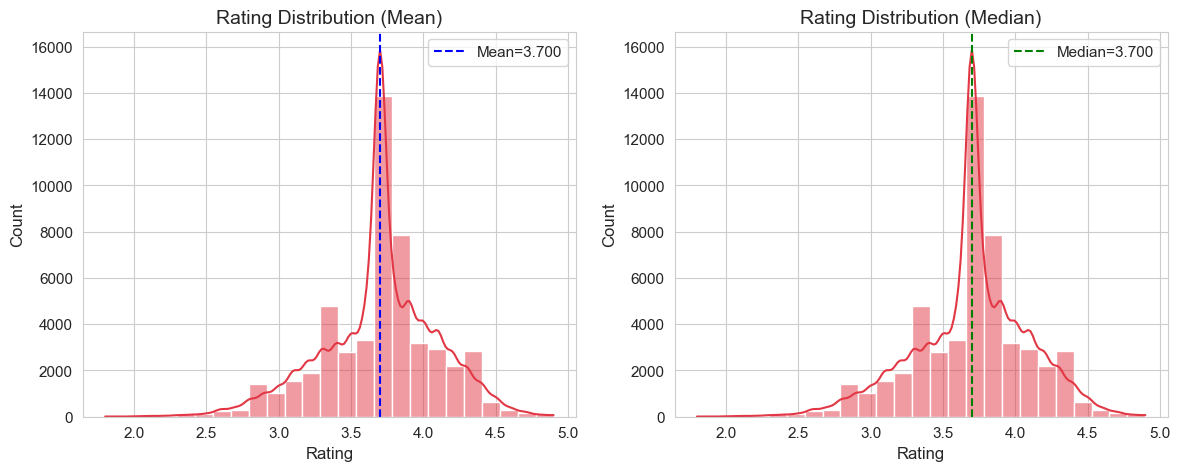

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["rate"], bins=25, kde=True, color="#E23744", ax=axes[0])
axes[0].set_title("Rating Distribution (Mean)")
axes[0].set_xlabel("Rating")
axes[0].axvline(
    df["rate"].mean(),
    color="blue", 
    linestyle="--",
    label=f'Mean={df["rate"].mean():.3f}'
)

sns.histplot(df["rate"], bins=25, kde=True, color="#E23744", ax=axes[1])

axes[1].axvline(
    df["rate"].median(),
    color="green",
    linestyle="--",
    label=f'Median={df["rate"].median():.3f}'
)

axes[1].set_title("Rating Distribution (Median)")
axes[1].set_xlabel("Rating")

axes[0].legend()
axes[1].legend()
plt.show()

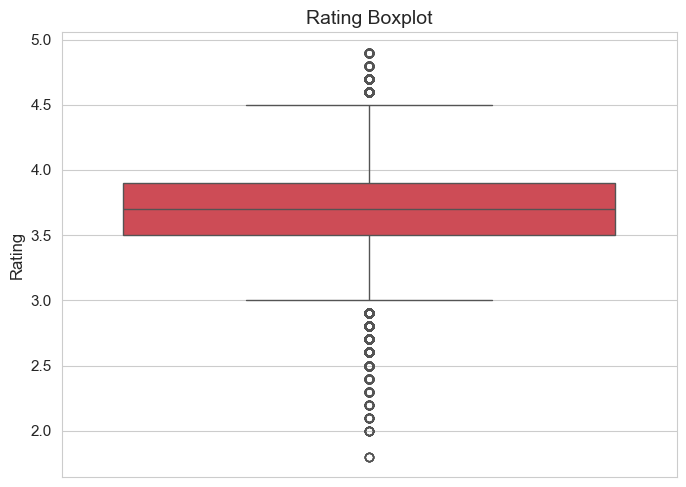

In [85]:
plt.figure(figsize=(7,5))


# sns.boxplot(y=df["rate"], bins=25, kde=True, color="#E23744", ax=axes[0])
sns.boxplot(y=df["rate"], color="#E23744")

plt.title("Rating Boxplot")
plt.ylabel("Rating")

plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [86]:
high_rated = df[df["rate"] > 4.5]
low_rated = df[df["rate"] < 3]

print("Num of High Rated Outliers (>4.5):", high_rated.shape[0])
print("Num of Low Rated Outliers (<3):", low_rated.shape[0])


Num of High Rated Outliers (>4.5): 587
Num of Low Rated Outliers (<3): 2256


##### Poorly(<3) rated restraunts are more frequent than highly(>4.5) rated ones.

In [87]:
print(df["rate"].describe())
print(f"Skewness: {df['rate'].skew():.3f}")
print(f"Kurtosis: {df['rate'].kurtosis():.3f}")


count    51632.000000
mean         3.700066
std          0.395331
min          1.800000
25%          3.500000
50%          3.700000
75%          3.900000
max          4.900000
Name: rate, dtype: float64
Skewness: -0.366
Kurtosis: 0.716




-------------------------------------------------------
### Insights :

- Distribution is centered properly
- No strong bias in middle
- 50% restrau. rated b/w `3.5 to 3.9`
- Very tight clustering around good ratings
- Negative skew : `left_skewed` , mild skewed
- `low_rated` outliers are more
-----------------------------------------------------------
- Kurtosis gives us the idea about the heaviness of tails ( extremeeee values ).
    - `>0` : more outliers
    - `<0` : Light tails
    -  ~0 : Normal distribution

****************************************
in our case :
`Kurtosis: 0.716 >0`
This +ve kurtosis tells the mild heavy tails and presence of some extreme rating values, but not in large qty.

Most restaurants are average-to-good, with a small but noticeable number of poorly rated places pulling the distribution slightly left.

### Cost Distrb.

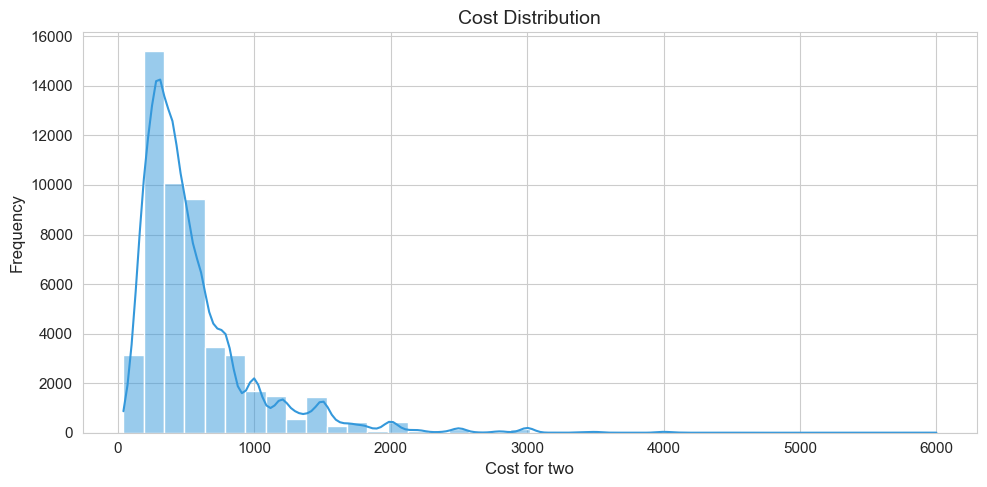

In [94]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["cost_for_two"],
    bins=40,
    kde=True,
    color="#3498DB",
    
)

plt.title("Cost Distribution")
plt.xlabel("Cost for two")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [96]:
print(df["cost_for_two"].describe())
print(f"Skewness: {df['cost_for_two'].skew():.3f}")
print(f"Kurtosis: {df['cost_for_two'].kurtosis():.3f}")


count    51632.000000
mean       554.042551
std        437.247299
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: cost_for_two, dtype: float64
Skewness: 2.619
Kurtosis: 10.589



---------------------------------------------------------
### Insights :

- Cost distribution is highly `right skewed`. ( `Skewness: 2.69` )
   - Most restraunts fall into **Budget & Affordable segments** , indicating strong presence of `low to mid range` dining opts.

- Dataset shows gradual decline in freq. as we move from `Budget to Luxury`, showing that `high cost` restraunts are rare. 

- Mean( Rs. 554) is higher than Median(Rs. 400) : Right Skewness confirmed.

- Luxury restaurants are very few in num. but act as high val. outliers in data.

-------------------------------------------------------

### Here in this case : 

`Kurtosis = 10.589` {'Very High'}

Heavy tails & presence of significant high val outliers

-----------------------------------
So..here we are .. From this `cost distribution` , we got to know that it is simply `Right Skewed`


Price segments clearlyyy shows : most restraunts cater to budget conscious customers, and with only a small fraction targetting premium/luxury dining experiences. 

This clearly reinforces the earlier observation of a right_skewed cost distribution. 

----------------------------------------------

Since dataset is `Right Skewed` , We will try 3 transformation ;-) 
1. `Log Transform`
2. `Square Root Transform`
3. `Yeo_Johnson`





## 0. Original

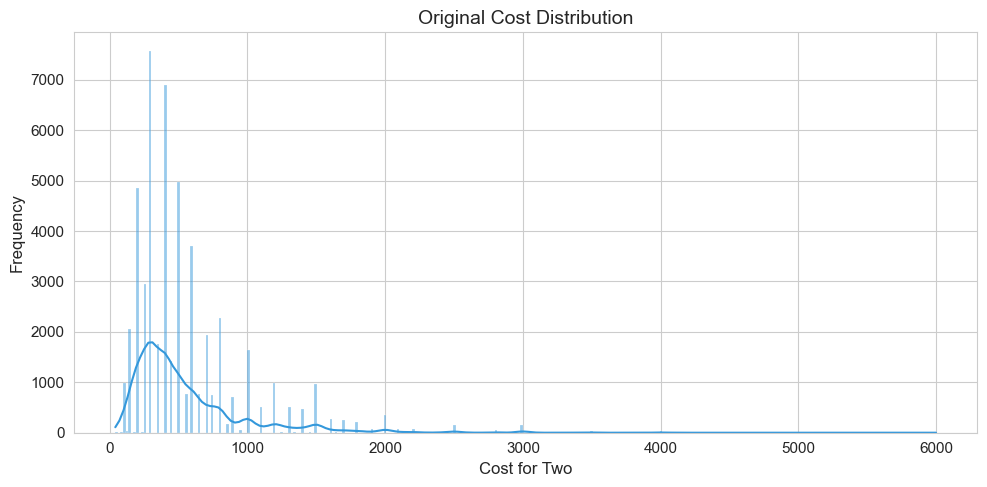

In [103]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["cost_for_two"],
    kde=True,
    color="#3498DB"
)

plt.title("Original Cost Distribution")
plt.xlabel("Cost for Two")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


## 1. Log Transform

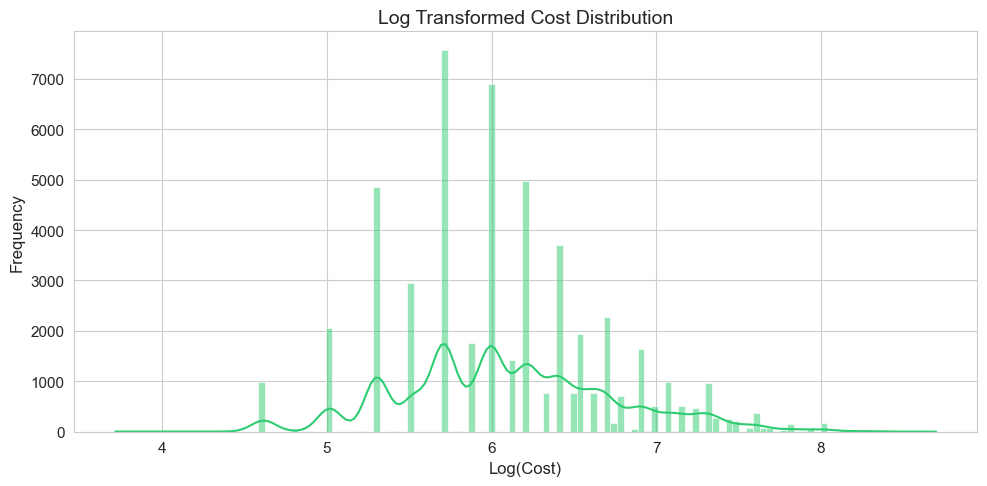

In [104]:
df["cost_log"] = np.log1p(df["cost_for_two"])

plt.figure(figsize=(10,5))

sns.histplot(
    df["cost_log"],
    kde=True,
    color="#2ECC71"
)

plt.title("Log Transformed Cost Distribution")
plt.xlabel("Log(Cost)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


## 2. Square Root Transform

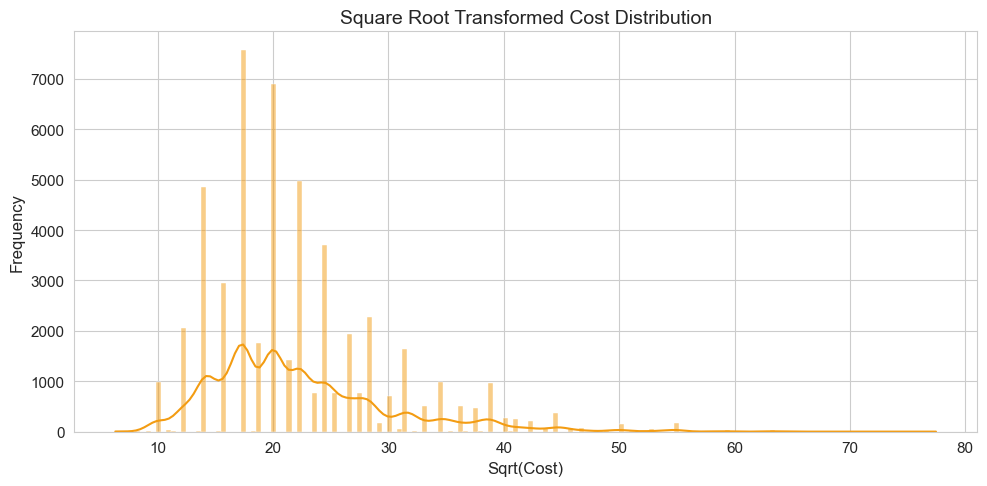

In [106]:
df["cost_sqrt"] = np.sqrt(df["cost_for_two"])

plt.figure(figsize=(10,5))

sns.histplot(
    df["cost_sqrt"],
    kde=True,
    color="#F39C12"
)

plt.title("Square Root Transformed Cost Distribution")
plt.xlabel("Sqrt(Cost)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



## 3. Yeo_Johnson Transform

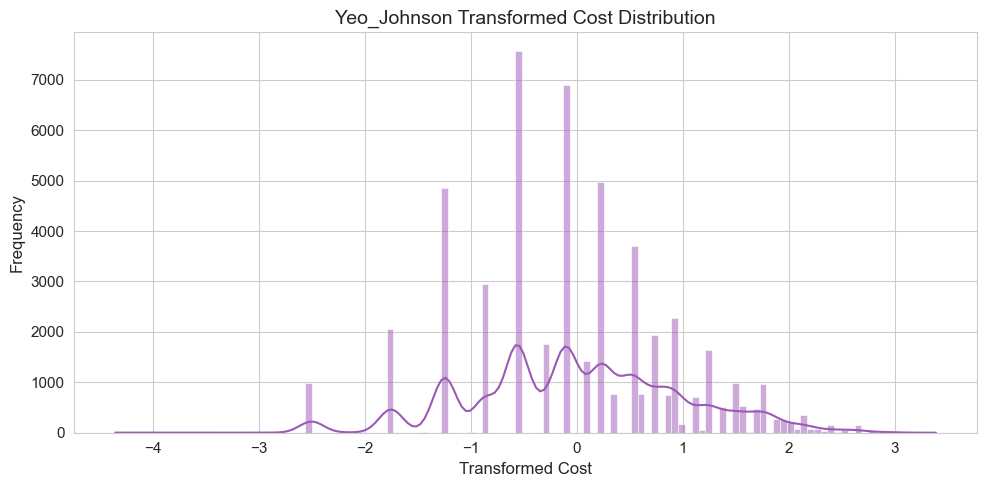

In [107]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")

df["cost_yeojohnson"] = pt.fit_transform(df[["cost_for_two"]])

plt.figure(figsize=(10,5))

sns.histplot(
    df["cost_yeojohnson"],
    kde=True,
    color="#9B59B6"
)

plt.title("Yeo_Johnson Transformed Cost Distribution")
plt.xlabel("Transformed Cost")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



By eyeballing graphs , we can figure out `Yeo-Johnson` and `Log1p` transform are good for bringing outliers closer to rest of the group.

------------------------------------------------------

We will be checking the best transformation using `skewness`

In [120]:
print("-"*20)
print("Skewness of 4 graphs")
print("-"*20)
print("Original: ", f'{df["cost_for_two"].skew():.3f}')
print("Log1p: ",f'{df["cost_log"].skew():.3f}')
print("Sqrt: ", f'{df["cost_sqrt"].skew():.3f}')
print("Yeo-Johnson: ", f'{df["cost_yeojohnson"].skew():.3f}')

--------------------
Skewness of 4 graphs
--------------------
Original:  2.619
Log1p:  0.285
Sqrt:  1.304
Yeo-Johnson:  0.001


## `Cost_for_two` Analysis :

So far we analyzed the column `cost_for_two` to understand its distribution and handle the skewness for further ML Model.


